In [16]:
import numpy as np
import os
from scipy.signal.windows import gaussian
from scipy.signal import convolve

# Parameters
num_signals_per_modulation = 1000  # Number of signals per modulation type
bit_length = 18                   # Ensuring bit-length compatibility with modulations
sampling_rate = 500              # 10 kHz sampling rate
duration = 1                       # Duration of each signal in seconds
modulation_types = ["GFSK", "BPSK", "QPSK", "8PSK", "QAM16", "QAM64"]
snr_db_list = [0, 4, 8, 12, 16]                 # Signal-to-Noise Ratio in dB
#freq_range = [3000, 5000, 7000, 10000, 15000]  # Carrier frequencies in kHz
#freq = np.random.uniform(100, 10000)  # Random frequency between 100 Hz and 10 kHz


# Function to add AWGN noise
def add_awgn_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise

# Gaussian Filter for GFSK
#def gaussian_filter(bits, width=5):
 #   filter_window = gaussian(6 * width, width)  
  #  filtered_bits = convolve(bits, filter_window / sum(filter_window), mode='same')
   # return filtered_bits

# Optimized GFSK Signal Generation
def generate_gfsk_signal(bits, freq, sampling_rate, duration, bt=0.3):
    """Generates a stable GFSK signal with Gaussian filtering."""
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_bit = len(t) // len(bits)
    modulated_signal = np.zeros_like(t)

    # Generate Gaussian filter
    filter_width = 4  # Reduced filter width for stability
    filter_window = gaussian(6 * filter_width, filter_width)
    filter_window /= sum(filter_window)  # Normalize filter

    # Apply Gaussian filtering to bits
    filtered_bits = convolve(bits, filter_window, mode='same')
    filtered_bits = np.clip(filtered_bits, 0, 1)  # Ensure values stay in [0, 1]

    for i, bit in enumerate(filtered_bits):
        freq_shift = freq + (bit - 0.5) * freq * bt  # Stable frequency shift with modulation index (bt)
        modulated_signal[i * samples_per_bit:(i + 1) * samples_per_bit] = \
            np.sin(2 * np.pi * freq_shift * t[i * samples_per_bit:(i + 1) * samples_per_bit])

    return t, modulated_signal

# BPSK Signal Generation
def generate_bpsk_signal(bits, freq, sampling_rate, duration):
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_bit = len(t) // len(bits)
    modulated_signal = np.zeros_like(t)
    for i, bit in enumerate(bits):
        phase = 0 if bit == 1 else np.pi
        modulated_signal[i * samples_per_bit:(i + 1) * samples_per_bit] = \
            np.sin(2 * np.pi * freq * t[i * samples_per_bit:(i + 1) * samples_per_bit] + phase)
    return t, modulated_signal

# Gray-coded QPSK Signal Generation
gray_qpsk_map = {
    (0, 0): 0,
    (0, 1): np.pi / 2,
    (1, 1): np.pi,
    (1, 0): 3 * np.pi / 2
}

def generate_qpsk_signal(bits, freq, sampling_rate, duration):
    if len(bits) % 2 != 0:
        raise ValueError("Bit sequence length must be even for QPSK.")
    
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_symbol = len(t) // (len(bits) // 2)
    modulated_signal = np.zeros_like(t)

    for i in range(0, len(bits), 2):
        symbol_bits = tuple(bits[i:i + 2])
        phase = gray_qpsk_map[symbol_bits]
        modulated_signal[(i // 2) * samples_per_symbol:((i // 2) + 1) * samples_per_symbol] = \
            np.sin(2 * np.pi * freq * t[(i // 2) * samples_per_symbol:((i // 2) + 1) * samples_per_symbol] + phase)
    
    return t, modulated_signal

# Gray-coded 8-PSK Signal Generation
gray_8psk_map = {
    (0, 0, 0): 0,
    (0, 0, 1): np.pi / 4,
    (0, 1, 1): np.pi / 2,
    (0, 1, 0): 3 * np.pi / 4,
    (1, 1, 0): np.pi,
    (1, 1, 1): 5 * np.pi / 4,
    (1, 0, 1): 3 * np.pi / 2,
    (1, 0, 0): 7 * np.pi / 4
}

def generate_8psk_signal(bits, freq, sampling_rate, duration):
    if len(bits) % 3 != 0:
        raise ValueError("Bit sequence length must be a multiple of 3 for 8-PSK.")
    
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_symbol = len(t) // (len(bits) // 3)
    modulated_signal = np.zeros_like(t)

    for i in range(0, len(bits), 3):
        symbol_bits = tuple(bits[i:i+3])
        phase = gray_8psk_map[symbol_bits]
        modulated_signal[(i // 3) * samples_per_symbol:((i // 3) + 1) * samples_per_symbol] = \
            np.sin(2 * np.pi * freq * t[(i // 3) * samples_per_symbol:((i // 3) + 1) * samples_per_symbol] + phase)
    
    return t, modulated_signal

# Gray-coded QAM Signal Generation
def generate_qam_signal(bits, freq, sampling_rate, duration, modulation_order=16):
    if modulation_order == 16:
        bits_per_symbol = 4
        levels = [-3, -1, 1, 3]  # Gray-coded 16-QAM
    elif modulation_order == 64:
        bits_per_symbol = 6
        levels = [-7, -5, -3, -1, 1, 3, 5, 7]  # Gray-coded 64-QAM
    else:
        raise ValueError("Unsupported modulation order for QAM.")

    if len(bits) % bits_per_symbol != 0:
        raise ValueError(f"Bit sequence length must be a multiple of {bits_per_symbol} for {modulation_order}-QAM.")

    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_symbol = len(t) // (len(bits) // bits_per_symbol)
    modulated_signal = np.zeros_like(t)

    for i in range(0, len(bits), bits_per_symbol):
        real_bits = int("".join(map(str, bits[i:i + bits_per_symbol // 2])), 2)
        imag_bits = int("".join(map(str, bits[i + bits_per_symbol // 2:i + bits_per_symbol])), 2)
        real_part = levels[real_bits % len(levels)]
        imag_part = levels[imag_bits % len(levels)]
        
        start_idx = (i // bits_per_symbol) * samples_per_symbol
        end_idx = start_idx + samples_per_symbol
        carrier_i = real_part * np.cos(2 * np.pi * freq * t[start_idx:end_idx])
        carrier_q = imag_part * np.sin(2 * np.pi * freq * t[start_idx:end_idx])
        modulated_signal[start_idx:end_idx] = carrier_i + carrier_q
    
    return t, modulated_signal 

# Generate Dataset
#dataset = []
#labels = []

dataset = []
labels = []
snr_values = []

# 6 modulations x 5 SNR values x 1000 signals each -> 30,000 total
for modulation_type in modulation_types:
    for snr in snr_db_list:
        for _ in range(num_signals_per_modulation):
            freq = np.random.uniform(100, 100000)

            if modulation_type == "QAM16":
                bits_per_symbol = 4
            elif modulation_type == "QAM64":
                bits_per_symbol = 6
            elif modulation_type == "8PSK":
                bits_per_symbol = 3
            else:
                bits_per_symbol = 1

            adjusted_bit_length = bit_length + (bits_per_symbol - bit_length % bits_per_symbol) % bits_per_symbol
            bits = np.random.randint(0, 2, adjusted_bit_length)

            # Generate baseband signal
            if modulation_type == "GFSK":
                _, signal = generate_gfsk_signal(bits, freq, sampling_rate, duration)
            elif modulation_type == "BPSK":
                _, signal = generate_bpsk_signal(bits, freq, sampling_rate, duration)
            elif modulation_type == "QPSK":
                _, signal = generate_qpsk_signal(bits, freq, sampling_rate, duration)
            elif modulation_type == "8PSK":
                _, signal = generate_8psk_signal(bits, freq, sampling_rate, duration)
            elif modulation_type == "QAM16":
                _, signal = generate_qam_signal(bits, freq, sampling_rate, duration, modulation_order=16)
            elif modulation_type == "QAM64":
                _, signal = generate_qam_signal(bits, freq, sampling_rate, duration, modulation_order=64)

            # Add noise
            noisy_signal = add_awgn_noise(signal, snr)
            dataset.append(noisy_signal)
            labels.append(modulation_type)
            snr_values.append(snr)  # ✅ Append SNR value for each sample

os.makedirs("dataset_200", exist_ok=True)
np.save("dataset_200/signals.npy", np.array(dataset, dtype=np.float32))
np.save("dataset_200/labels.npy", np.array(labels))
np.save("dataset_200/snrs.npy", np.array(snr_values, dtype=np.int32))  # Save SNR values


num_samples = len(dataset)
print(f"Dataset saved successfully as 'dataset_31' with all 6 modulations at 5 SNR levels!")
print(f"Total samples: {num_samples}")  

Dataset saved successfully as 'dataset_31' with all 6 modulations at 5 SNR levels!
Total samples: 30000


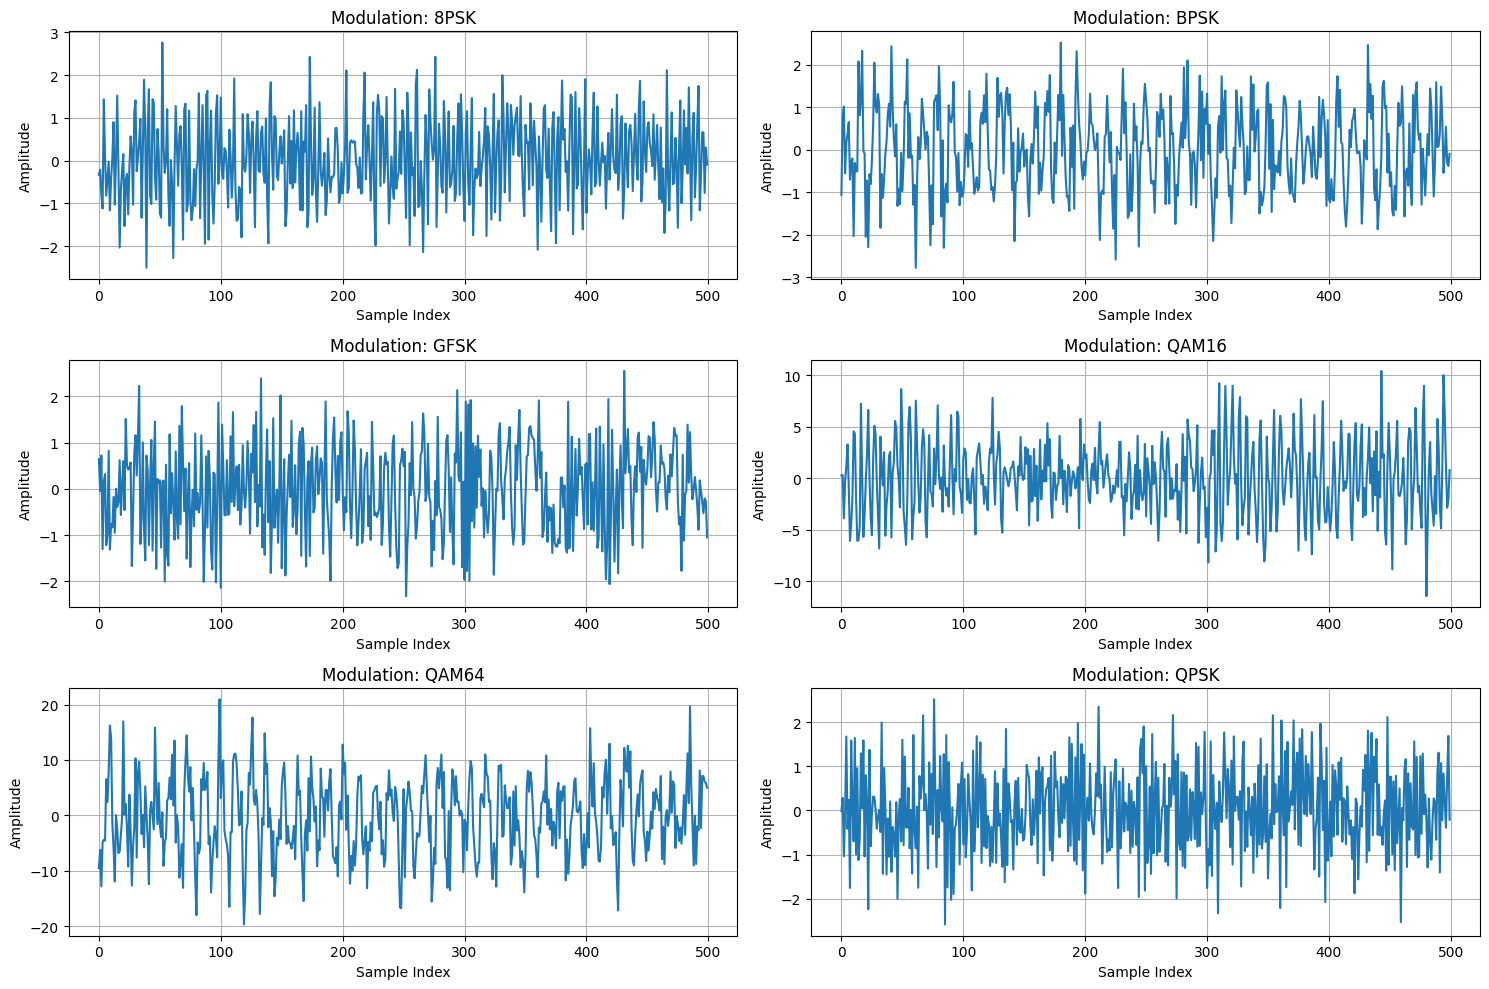

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
signals = np.load("dataset_200/signals.npy")
labels = np.load("dataset_200/labels.npy")

# Unique Modulation Types
modulation_types = np.unique(labels)

# Initialize the plot
plt.figure(figsize=(15, 10))

for i, modulation in enumerate(modulation_types):
    # Get the first signal corresponding to each modulation type
    signal_index = np.where(labels == modulation)[0][0]
    signal = signals[signal_index]

    # Plot the real part of the signal
    plt.subplot(3, 2, i + 1)
    plt.plot(signal.real[:1000])  # Plot the first 1000 samples
    plt.title(f"Modulation: {modulation}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np

dataset_path = "dataset_200"

# Load data
signals = np.load(f"{dataset_path}/signals.npy")
labels = np.load(f"{dataset_path}/labels.npy", allow_pickle=True)  # Ensure it's loaded correctly
snrs = np.load(f"{dataset_path}/snrs.npy")

# Convert labels and snrs to NumPy arrays (if they are lists)
if isinstance(labels, list):
    labels = np.array(labels)
if isinstance(snrs, list):
    snrs = np.array(snrs)

# Print shapes
print(f"Signals shape: {signals.shape}")
print(f"Labels shape: {labels.shape}")
print(f"SNRs shape: {snrs.shape}")


Signals shape: (30000, 500)
Labels shape: (30000,)
SNRs shape: (30000,)


In [3]:
import numpy as np

# Load your dataset
signals = np.load("dataset_200/signals.npy")

# Count the number of samples
num_samples = signals.shape[0]

# Print the number of samples
print(f"Total number of samples in the dataset: {num_samples}")


Total number of samples in the dataset: 30000


In [21]:
import numpy as np
import os

# Load dataset
dataset_path = "dataset_200"
signals = np.load(os.path.join(dataset_path, "signals.npy"))
labels = np.load(os.path.join(dataset_path, "labels.npy"))
snrs = np.load(os.path.join(dataset_path, "snrs.npy"))

# Define parameters
num_train_samples = 800  # Per modulation per SNR
num_test_samples = 200   # Per modulation per SNR
modulation_types = ["GFSK", "BPSK", "QPSK", "8PSK", "QAM16", "QAM64"]
snr_levels = [0, 4, 8, 12, 16]

# Containers for train/test sets
train_signals, train_labels = [], []
test_data_by_snr = {snr: {"signals": [], "labels": []} for snr in snr_levels}

# Assign samples per modulation and SNR
for mod in modulation_types:
    mod_mask = labels == mod  # Get all indices for this modulation
    mod_signals, mod_labels, mod_snrs = signals[mod_mask], labels[mod_mask], snrs[mod_mask]
    
    for snr in snr_levels:
        snr_mask = mod_snrs == snr  # Filter samples for this modulation & SNR
        snr_indices = np.where(snr_mask)[0]

        # Ensure enough samples
        if len(snr_indices) < num_train_samples + num_test_samples:
            print(f"⚠️ Warning: Not enough samples for {mod} at {snr} dB!")

        # Shuffle & split
        np.random.shuffle(snr_indices)
        train_idx = snr_indices[:num_train_samples]
        test_idx = snr_indices[num_train_samples:num_train_samples + num_test_samples]

        # Add to training set
        train_signals.append(mod_signals[train_idx])
        train_labels.extend([mod] * len(train_idx))

        # Add to test set per SNR
        test_data_by_snr[snr]["signals"].append(mod_signals[test_idx])
        test_data_by_snr[snr]["labels"].extend([mod] * len(test_idx))

# Convert lists to numpy arrays
train_signals = np.concatenate(train_signals)
train_labels = np.array(train_labels)

# Save training dataset
np.save(os.path.join(dataset_path, "200_train_signals.npy"), train_signals)
np.save(os.path.join(dataset_path, "200_train_labels.npy"), train_labels)

# Save test datasets per SNR
for snr in snr_levels:
    test_signals = np.concatenate(test_data_by_snr[snr]["signals"])
    test_labels = np.array(test_data_by_snr[snr]["labels"])
    
    np.save(os.path.join(dataset_path, f"200_test_signals_snr{snr}.npy"), test_signals)
    np.save(os.path.join(dataset_path, f"200_test_labels_snr{snr}.npy"), test_labels)
    
    print(f"✅ Saved {len(test_signals)} samples for SNR {snr} dB.")

print("\n✅ Training and SNR-separated testing datasets have been successfully created and saved in .npy format!")


✅ Saved 1200 samples for SNR 0 dB.
✅ Saved 1200 samples for SNR 4 dB.
✅ Saved 1200 samples for SNR 8 dB.
✅ Saved 1200 samples for SNR 12 dB.
✅ Saved 1200 samples for SNR 16 dB.

✅ Training and SNR-separated testing datasets have been successfully created and saved in .npy format!


In [11]:
import numpy as np
import joblib
import os
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import skew, kurtosis
from scipy.signal.windows import gaussian
from scipy.signal import convolve

# ========== LOAD DATASET ==========
signals = np.load("dataset_200/signals.npy")
labels = np.load("dataset_200/labels.npy")

# ========== ENCODE LABELS ==========
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# ========== FEATURE EXTRACTION FUNCTIONS ==========

def calculate_moments(data):
    """Calculate statistical moments: mean, variance, skewness, and kurtosis."""
    mean = np.nan_to_num(np.mean(data))
    var = np.nan_to_num(np.var(data))
    skewness = np.nan_to_num(skew(data))
    kurt_val = np.nan_to_num(kurtosis(data))
    return mean, var, skewness, kurt_val

def extract_features(signal):
    """
    Extract robust features including higher-order moments (Mij), cumulants, 
    higher-order ratios, spectral features, and power-based features.
    """
    # Convert to real/imag just in case signals are complex (though they might be real)
    real_part = np.nan_to_num(signal.real)
    imag_part = np.nan_to_num(signal.imag)
    magnitude = np.nan_to_num(np.abs(signal))

    # Higher-order moments
    m10 = np.mean(real_part)
    m20 = np.mean(real_part ** 2)
    m30 = np.mean(real_part ** 3)
    m01 = np.mean(imag_part)
    m11 = np.mean(real_part * imag_part)
    m21 = np.mean(real_part ** 2 * imag_part)
    m12 = np.mean(real_part * imag_part ** 2)
    m03 = np.mean(imag_part ** 3)

    # Statistical moments (Real & Imag)
    mean_r, var_r, skew_r, kurt_r = calculate_moments(real_part)
    mean_i, var_i, skew_i, kurt_i = calculate_moments(imag_part)

    # Cumulants (example placeholders; ensure definitions match your usage)
    c20 = np.mean(signal ** 2)
    c21 = np.mean(np.abs(signal) ** 2)
    c40 = np.mean(signal ** 4) - 3 * c20 ** 2
    c41 = np.mean(signal ** 4 * np.conj(signal)) - 3 * c20 * c21
    c42 = np.mean(signal ** 4) - 2 * c21 - np.abs(c21) ** 2
    c60 = np.mean(signal ** 6) - 15 * c40 * c20 - 10 * c20 ** 3
    c80 = np.mean(signal ** 8) - 28 * c60 * c20 - 35 * c40 ** 2

    # Higher-order ratios (HoR) - placeholders
    r1 = np.abs(c40) / (np.abs(c42) + 1e-10)
    r2 = np.abs(c41) / (np.abs(c42) + 1e-10)
    r3 = np.abs(c42) / (np.abs(c21) ** 2 + 1e-10)
    r4 = np.abs(c60) / (np.abs(c21) ** 3 + 1e-10)
    r5 = np.abs(c80) / (np.abs(c21) ** 2 + 1e-10)
    r6 = np.abs(c80) / (np.abs(c42) ** 3 + 1e-10)

    # Spectral features
    fft_vals = np.fft.fft(signal)
    power_spectrum = np.abs(fft_vals) ** 2 + 1e-10
    spectral_energy = np.sum(power_spectrum)
    p_spectrum_norm = power_spectrum / (spectral_energy + 1e-10)
    spectral_entropy = -np.sum(p_spectrum_norm * np.log2(p_spectrum_norm + 1e-10))

    # Power-based features
    papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
    crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

    features = [
        m10, m20, m30, m01, m11, m21, m12, m03,
        mean_r, var_r, skew_r, kurt_r,
        mean_i, var_i, skew_i, kurt_i,
        c20, c21, c40, c41, c42, c60, c80,
        r1, r2, r3, r4, r5, r6,
        spectral_energy, spectral_entropy,
        papr, crest_factor
    ]

    # Replace any potential NaN or Inf with numeric 0
    return np.nan_to_num(features)

# ========== EXTRACT FEATURES FOR FULL DATASET ==========
features_list = [extract_features(sig) for sig in signals]
features_array = np.array(features_list, dtype=np.float32)

# ========== SCALING AND PCA FIT (TRAINING) ==========
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_array)

# Choose the number of principal components. 
# For demonstration, 13 is just an example. Adjust to your preference or dataset dimension.
pca = PCA(n_components=13)
features_pca = pca.fit_transform(features_scaled)

# ========== SVM TRAINING ON ENTIRE DATASET ==========
svm_model = SVC(kernel="linear", C=2.0, random_state=42)
svm_model.fit(features_pca, labels_encoded)

# ========== SAVE THE TRAINED MODEL AND PREPROCESSORS ==========
os.makedirs("svm_model_files", exist_ok=True)
joblib.dump(svm_model, "svm_model_files/200_stable_svm_modulation_classifier.pkl")
joblib.dump(scaler, "svm_model_files/200_scaler.pkl")
joblib.dump(pca, "svm_model_files/200_pca_transform.pkl")
joblib.dump(label_encoder, "svm_model_files/200_label_encoder.pkl")

print("Model and preprocessing objects have been saved.")
print(f"Total number of samples used for training: {len(labels)}")


Model and preprocessing objects have been saved.
Total number of samples used for training: 24000


In [4]:
import numpy as np
import os
from scipy.signal.windows import gaussian
from scipy.signal import convolve

# Parameters
num_signals_per_modulation = 200  # Number of signals per modulation type
bit_length = 18                   # Ensuring bit-length compatibility with modulations
sampling_rate = 500              # 10 kHz sampling rate
duration = 1                       # Duration of each signal in seconds
modulation_types = ["GFSK", "BPSK", "QPSK", "8PSK", "QAM16", "QAM64"]
snr_db = 4                # Signal-to-Noise Ratio in dB
#freq_range = [3000, 5000, 7000, 10000, 15000]  # Carrier frequencies in kHz
#freq = np.random.uniform(100, 10000)  # Random frequency between 100 Hz and 10 kHz


# Function to add AWGN noise
def add_awgn_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.normal(size=signal.shape)
    return signal + noise

# Gaussian Filter for GFSK
#def gaussian_filter(bits, width=5):
 #   filter_window = gaussian(6 * width, width)  
  #  filtered_bits = convolve(bits, filter_window / sum(filter_window), mode='same')
   # return filtered_bits

# Optimized GFSK Signal Generation
def generate_gfsk_signal(bits, freq, sampling_rate, duration, bt=0.3):
    """Generates a stable GFSK signal with Gaussian filtering."""
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_bit = len(t) // len(bits)
    modulated_signal = np.zeros_like(t)

    # Generate Gaussian filter
    filter_width = 4  # Reduced filter width for stability
    filter_window = gaussian(6 * filter_width, filter_width)
    filter_window /= sum(filter_window)  # Normalize filter

    # Apply Gaussian filtering to bits
    filtered_bits = convolve(bits, filter_window, mode='same')
    filtered_bits = np.clip(filtered_bits, 0, 1)  # Ensure values stay in [0, 1]

    for i, bit in enumerate(filtered_bits):
        freq_shift = freq + (bit - 0.5) * freq * bt  # Stable frequency shift with modulation index (bt)
        modulated_signal[i * samples_per_bit:(i + 1) * samples_per_bit] = \
            np.sin(2 * np.pi * freq_shift * t[i * samples_per_bit:(i + 1) * samples_per_bit])

    return t, modulated_signal

# BPSK Signal Generation
def generate_bpsk_signal(bits, freq, sampling_rate, duration):
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_bit = len(t) // len(bits)
    modulated_signal = np.zeros_like(t)
    for i, bit in enumerate(bits):
        phase = 0 if bit == 1 else np.pi
        modulated_signal[i * samples_per_bit:(i + 1) * samples_per_bit] = \
            np.sin(2 * np.pi * freq * t[i * samples_per_bit:(i + 1) * samples_per_bit] + phase)
    return t, modulated_signal

# Gray-coded QPSK Signal Generation
gray_qpsk_map = {
    (0, 0): 0,
    (0, 1): np.pi / 2,
    (1, 1): np.pi,
    (1, 0): 3 * np.pi / 2
}

def generate_qpsk_signal(bits, freq, sampling_rate, duration):
    if len(bits) % 2 != 0:
        raise ValueError("Bit sequence length must be even for QPSK.")
    
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_symbol = len(t) // (len(bits) // 2)
    modulated_signal = np.zeros_like(t)

    for i in range(0, len(bits), 2):
        symbol_bits = tuple(bits[i:i + 2])
        phase = gray_qpsk_map[symbol_bits]
        modulated_signal[(i // 2) * samples_per_symbol:((i // 2) + 1) * samples_per_symbol] = \
            np.sin(2 * np.pi * freq * t[(i // 2) * samples_per_symbol:((i // 2) + 1) * samples_per_symbol] + phase)
    
    return t, modulated_signal

# Gray-coded 8-PSK Signal Generation
gray_8psk_map = {
    (0, 0, 0): 0,
    (0, 0, 1): np.pi / 4,
    (0, 1, 1): np.pi / 2,
    (0, 1, 0): 3 * np.pi / 4,
    (1, 1, 0): np.pi,
    (1, 1, 1): 5 * np.pi / 4,
    (1, 0, 1): 3 * np.pi / 2,
    (1, 0, 0): 7 * np.pi / 4
}

def generate_8psk_signal(bits, freq, sampling_rate, duration):
    if len(bits) % 3 != 0:
        raise ValueError("Bit sequence length must be a multiple of 3 for 8-PSK.")
    
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_symbol = len(t) // (len(bits) // 3)
    modulated_signal = np.zeros_like(t)

    for i in range(0, len(bits), 3):
        symbol_bits = tuple(bits[i:i+3])
        phase = gray_8psk_map[symbol_bits]
        modulated_signal[(i // 3) * samples_per_symbol:((i // 3) + 1) * samples_per_symbol] = \
            np.sin(2 * np.pi * freq * t[(i // 3) * samples_per_symbol:((i // 3) + 1) * samples_per_symbol] + phase)
    
    return t, modulated_signal

# Gray-coded QAM Signal Generation
def generate_qam_signal(bits, freq, sampling_rate, duration, modulation_order=16):
    if modulation_order == 16:
        bits_per_symbol = 4
        levels = [-3, -1, 1, 3]  # Gray-coded 16-QAM
    elif modulation_order == 64:
        bits_per_symbol = 6
        levels = [-7, -5, -3, -1, 1, 3, 5, 7]  # Gray-coded 64-QAM
    else:
        raise ValueError("Unsupported modulation order for QAM.")

    if len(bits) % bits_per_symbol != 0:
        raise ValueError(f"Bit sequence length must be a multiple of {bits_per_symbol} for {modulation_order}-QAM.")

    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    samples_per_symbol = len(t) // (len(bits) // bits_per_symbol)
    modulated_signal = np.zeros_like(t)

    for i in range(0, len(bits), bits_per_symbol):
        real_bits = int("".join(map(str, bits[i:i + bits_per_symbol // 2])), 2)
        imag_bits = int("".join(map(str, bits[i + bits_per_symbol // 2:i + bits_per_symbol])), 2)
        real_part = levels[real_bits % len(levels)]
        imag_part = levels[imag_bits % len(levels)]
        
        start_idx = (i // bits_per_symbol) * samples_per_symbol
        end_idx = start_idx + samples_per_symbol
        carrier_i = real_part * np.cos(2 * np.pi * freq * t[start_idx:end_idx])
        carrier_q = imag_part * np.sin(2 * np.pi * freq * t[start_idx:end_idx])
        modulated_signal[start_idx:end_idx] = carrier_i + carrier_q
    
    return t, modulated_signal 

# Generate Dataset
dataset = []
labels = []

for modulation_type in modulation_types:
    for _ in range(num_signals_per_modulation):
        freq = np.random.uniform(10000, 100000)  

        if modulation_type in ["QAM16"]:
            bits_per_symbol = 4
        elif modulation_type in ["QAM64"]:
            bits_per_symbol = 6
        elif modulation_type == "8PSK":
            bits_per_symbol = 3
        else:
            bits_per_symbol = 1

        adjusted_bit_length = bit_length + (bits_per_symbol - bit_length % bits_per_symbol) % bits_per_symbol
        bits = np.random.randint(0, 2, adjusted_bit_length)

        if modulation_type == "GFSK":
            _, signal = generate_gfsk_signal(bits, freq, sampling_rate, duration)
        elif modulation_type == "BPSK":
            _, signal = generate_bpsk_signal(bits, freq, sampling_rate, duration)
        elif modulation_type == "QPSK":
            _, signal = generate_qpsk_signal(bits, freq, sampling_rate, duration)
        elif modulation_type == "8PSK":
            _, signal = generate_8psk_signal(bits, freq, sampling_rate, duration)
        elif modulation_type == "QAM16":
            _, signal = generate_qam_signal(bits, freq, sampling_rate, duration, modulation_order=16)
        elif modulation_type == "QAM64":
            _, signal = generate_qam_signal(bits, freq, sampling_rate, duration, modulation_order=64)

        noisy_signal = add_awgn_noise(signal, snr_db)
        dataset.append(noisy_signal)
        labels.append(modulation_type)

# Save Dataset as "dataset_2"
os.makedirs("dataset_M0", exist_ok=True)
np.save("dataset_M0/signals.npy", np.array(dataset, dtype=np.float32))
np.save("dataset_M0/labels.npy", np.array(labels))

print("Dataset saved successfully as 'dataset_31' with all 6 modulations!")

Dataset saved successfully as 'dataset_31' with all 6 modulations!


In [12]:
import numpy as np
import joblib
from scipy.stats import skew, kurtosis

##############################
# 1) LOAD NEW TEST SIGNALS
##############################

# Suppose your new signals are in "my_test_signals.npy"
# You can change this file path to the actual location of your new dataset.
new_signals = np.load("dataset_M0/signals.npy")

##############################
# 2) LOAD PRETRAINED MODEL & PREPROCESSORS
##############################

# Load the saved SVM model, scaler, PCA transform, and label encoder
svm_model = joblib.load("svm_model_files/200_stable_svm_modulation_classifier.pkl")
scaler = joblib.load("svm_model_files/200_scaler.pkl")
pca = joblib.load("svm_model_files/200_pca_transform.pkl")
label_encoder = joblib.load("svm_model_files/200_label_encoder.pkl")

##############################
# 3) DEFINE FEATURE EXTRACTION
##############################

def calculate_moments(data):
    """Calculate statistical moments: mean, variance, skewness, and kurtosis."""
    mean = np.nan_to_num(np.mean(data))
    var = np.nan_to_num(np.var(data))
    skewness = np.nan_to_num(skew(data))
    kurt_val = np.nan_to_num(kurtosis(data))
    return mean, var, skewness, kurt_val

def extract_features(signal):
    """Extract robust features from the signal."""
    # Convert to real/imag if you expect complex
    real_part = np.nan_to_num(signal.real)
    imag_part = np.nan_to_num(signal.imag)
    magnitude = np.nan_to_num(np.abs(signal))

    # Higher-order moments
    m10 = np.mean(real_part)
    m20 = np.mean(real_part ** 2)
    m30 = np.mean(real_part ** 3)
    m01 = np.mean(imag_part)
    m11 = np.mean(real_part * imag_part)
    m21 = np.mean(real_part ** 2 * imag_part)
    m12 = np.mean(real_part * imag_part ** 2)
    m03 = np.mean(imag_part ** 3)

    # Statistical moments
    mean_r, var_r, skew_r, kurt_r = calculate_moments(real_part)
    mean_i, var_i, skew_i, kurt_i = calculate_moments(imag_part)

    # Example cumulants (from training code)
    c20 = np.mean(signal ** 2)
    c21 = np.mean(np.abs(signal) ** 2)
    c40 = np.mean(signal ** 4) - 3 * c20 ** 2
    c41 = np.mean(signal ** 4 * np.conj(signal)) - 3 * c20 * c21
    c42 = np.mean(signal ** 4) - 2 * c21 - np.abs(c21) ** 2
    c60 = np.mean(signal ** 6) - 15 * c40 * c20 - 10 * c20 ** 3
    c80 = np.mean(signal ** 8) - 28 * c60 * c20 - 35 * c40 ** 2

    # Higher-order ratios
    r1 = np.abs(c40) / (np.abs(c42) + 1e-10)
    r2 = np.abs(c41) / (np.abs(c42) + 1e-10)
    r3 = np.abs(c42) / ((np.abs(c21) ** 2) + 1e-10)
    r4 = np.abs(c60) / ((np.abs(c21) ** 3) + 1e-10)
    r5 = np.abs(c80) / ((np.abs(c21) ** 2) + 1e-10)
    r6 = np.abs(c80) / ((np.abs(c42) ** 3) + 1e-10)

    # Spectral features
    fft_vals = np.fft.fft(signal)
    power_spectrum = np.abs(fft_vals) ** 2 + 1e-10
    spectral_energy = np.sum(power_spectrum)
    p_spectrum_norm = power_spectrum / (spectral_energy + 1e-10)
    spectral_entropy = -np.sum(p_spectrum_norm * np.log2(p_spectrum_norm + 1e-10))

    # Power-based features
    papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
    crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

    features = [
        m10, m20, m30, m01, m11, m21, m12, m03,
        mean_r, var_r, skew_r, kurt_r,
        mean_i, var_i, skew_i, kurt_i,
        c20, c21, c40, c41, c42, c60, c80,
        r1, r2, r3, r4, r5, r6,
        spectral_energy, spectral_entropy,
        papr, crest_factor
    ]

    return np.nan_to_num(features)

##############################
# 4) EXTRACT FEATURES FOR NEW DATA
##############################

new_features_list = [extract_features(signal) for signal in new_signals]
new_features_array = np.array(new_features_list, dtype=np.float32)

##############################
# 5) APPLY SCALER & PCA
##############################
new_features_scaled = scaler.transform(new_features_array)
new_features_pca = pca.transform(new_features_scaled)

##############################
# 6) PREDICT WITH LOADED MODEL
##############################
predictions_encoded = svm_model.predict(new_features_pca)
predictions = label_encoder.inverse_transform(predictions_encoded)

##############################
# 7) DISPLAY OR SAVE RESULTS
##############################
print("Predicted modulations for test signals:")
print(predictions)


Predicted modulations for test signals:
['GFSK' 'GFSK' 'GFSK' ... 'QAM64' 'QAM64' 'QAM64']


Classification Report:
              precision    recall  f1-score   support

        8PSK       0.72      0.73      0.73       200
        BPSK       0.95      0.87      0.91       200
        GFSK       1.00      0.98      0.99       200
       QAM16       0.98      0.99      0.99       200
       QAM64       0.99      0.97      0.98       200
        QPSK       0.64      0.70      0.67       200

    accuracy                           0.88      1200
   macro avg       0.88      0.88      0.88      1200
weighted avg       0.88      0.88      0.88      1200

Confusion Matrix:
[[147   0   0   0   0  53]
 [  1 174   0   0   0  25]
 [  0   3 197   0   0   0]
 [  0   0   0 199   1   0]
 [  1   0   0   4 195   0]
 [ 54   6   0   0   0 140]]


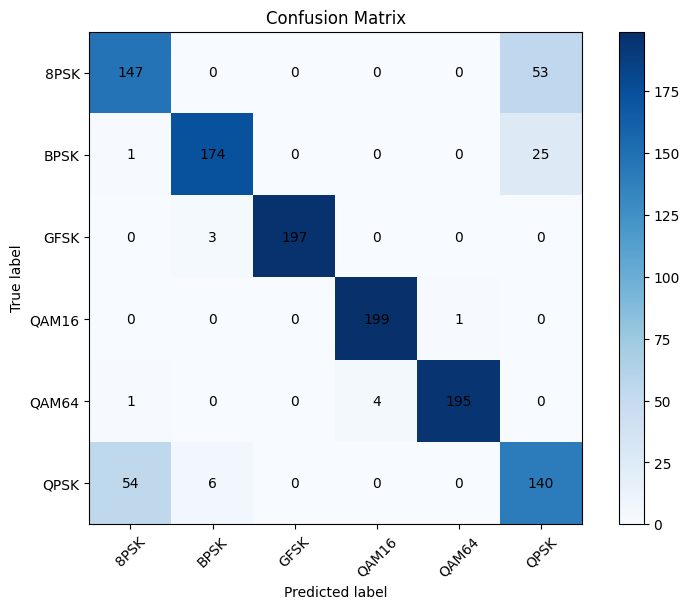

In [1]:
import numpy as np
import joblib
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

##############################
# 1) LOAD NEW TEST SIGNALS AND LABELS
##############################
# Replace these file paths with your actual test set
new_signals = np.load("dataset_M0/signals.npy") 
test_labels = np.load("dataset_M0/labels.npy")  # Ground truth for confusion matrix & report

##############################
# 2) LOAD PRETRAINED MODEL & PREPROCESSORS
##############################
# The model is saved by default as "stable_svm_modulation_classifier.pkl" 
svm_model = joblib.load("svm_model_files/200_stable_svm_modulation_classifier.pkl")
scaler = joblib.load("svm_model_files/200_scaler.pkl")
pca = joblib.load("svm_model_files/200_pca_transform.pkl")
label_encoder = joblib.load("svm_model_files/200_label_encoder.pkl")

##############################
# 3) DEFINE FEATURE EXTRACTION (EXACTLY AS TRAINING)
##############################
def calculate_moments(data):
    """Calculate statistical moments: mean, variance, skewness, and kurtosis."""
    mean = np.mean(data)
    var = np.var(data)
    skew_val = skew(data)
    kurt_val = kurtosis(data)
    return np.nan_to_num(mean), np.nan_to_num(var), np.nan_to_num(skew_val), np.nan_to_num(kurt_val)

def extract_features(signal):
    """Extract features exactly as in the training phase."""
    # Convert to real/imag if signals might be complex
    real_part = np.nan_to_num(signal.real)
    imag_part = np.nan_to_num(signal.imag)
    magnitude = np.nan_to_num(np.abs(signal))

    # Higher-order moments
    m10 = np.mean(real_part)
    m20 = np.mean(real_part ** 2)
    m30 = np.mean(real_part ** 3)
    m01 = np.mean(imag_part)
    m11 = np.mean(real_part * imag_part)
    m21 = np.mean(real_part ** 2 * imag_part)
    m12 = np.mean(real_part * imag_part ** 2)
    m03 = np.mean(imag_part ** 3)

    # Statistical moments (real & imag)
    mean_r, var_r, skew_r, kurt_r = calculate_moments(real_part)
    mean_i, var_i, skew_i, kurt_i = calculate_moments(imag_part)

    # Example cumulants (must match training definitions)
    c20 = np.mean(signal ** 2)
    c21 = np.mean(magnitude ** 2)
    c40 = np.mean(signal ** 4) - 3 * c20 ** 2
    c41 = np.mean(signal ** 4 * np.conj(signal)) - 3 * c20 * c21
    c42 = np.mean(signal ** 4) - 2 * c21 - np.abs(c21) ** 2
    c60 = np.mean(signal ** 6) - 15 * c40 * c20 - 10 * c20 ** 3
    c80 = np.mean(signal ** 8) - 28 * c60 * c20 - 35 * c40 ** 2

    # Higher-order ratios
    r1 = np.abs(c40) / (np.abs(c42) + 1e-10)
    r2 = np.abs(c41) / (np.abs(c42) + 1e-10)
    r3 = np.abs(c42) / (np.abs(c21) ** 2 + 1e-10)
    r4 = np.abs(c60) / (np.abs(c21) ** 3 + 1e-10)
    r5 = np.abs(c80) / (np.abs(c21) ** 2 + 1e-10)
    r6 = np.abs(c80) / (np.abs(c42) ** 3 + 1e-10)

    # Spectral features
    fft_vals = np.fft.fft(signal)
    power_spectrum = np.abs(fft_vals) ** 2 + 1e-10
    spectral_energy = np.sum(power_spectrum)
    p_spectrum_norm = power_spectrum / (spectral_energy + 1e-10)
    spectral_entropy = -np.sum(p_spectrum_norm * np.log2(p_spectrum_norm + 1e-10))

    # Power-based features
    papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
    crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

    # Combine all features
    features = [
        m10, m20, m30, m01, m11, m21, m12, m03,
        mean_r, var_r, skew_r, kurt_r,
        mean_i, var_i, skew_i, kurt_i,
        c20, c21, c40, c41, c42, c60, c80,
        r1, r2, r3, r4, r5, r6,
        spectral_energy, spectral_entropy,
        papr, crest_factor
    ]

    return np.nan_to_num(features)


##############################
# 4) EXTRACT FEATURES FOR THE TEST SET
##############################
new_features = [extract_features(sig) for sig in new_signals]
new_features_array = np.array(new_features, dtype=np.float32)

##############################
# 5) SCALE + PCA TRANSFORM
##############################
new_features_scaled = scaler.transform(new_features_array)
new_features_pca = pca.transform(new_features_scaled)

##############################
# 6) MAKE PREDICTIONS
##############################
predicted_labels_encoded = svm_model.predict(new_features_pca)
predicted_labels = label_encoder.inverse_transform(predicted_labels_encoded)

##############################
# 7) EVALUATE: CONFUSION MATRIX & CLASSIFICATION REPORT
##############################
# Encode the ground-truth labels to match model output
true_labels_encoded = label_encoder.transform(test_labels)

conf_matrix = confusion_matrix(true_labels_encoded, predicted_labels_encoded)
report = classification_report(true_labels_encoded, predicted_labels_encoded, target_names=label_encoder.classes_)

print("Classification Report:")
print(report)

print("Confusion Matrix:")
print(conf_matrix)

# Optional: Plot Confusion Matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

# Annotate cells
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j],
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

##############################
# 8) PRINT PREDICTIONS (OPTIONAL)
##############################
#print("Predicted modulations for test signals:")
#for i, pred in enumerate(predicted_labels):
 #   print(f"Signal {i}: {pred}")


In [5]:
import numpy as np
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt
import os

# -------------------------------
# Load Dataset
# -------------------------------
signals = np.load("dataset_200/signals.npy")
labels = np.load("dataset_200/labels.npy")

# Encode Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)

# -------------------------------
# Feature Extraction Function
# -------------------------------
def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.nan_to_num(np.abs(signal))
        signal_skew = skew(signal)
        signal_kurtosis = kurtosis(signal)
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
        mad = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        activity = np.var(signal)
        mobility = np.sqrt(np.var(np.diff(signal)) / activity) if activity != 0 else 0
        complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / mobility) if mobility != 0 else 0
        fft_signal = np.abs(fft(signal))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid)**2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2 + 1e-10)
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal, 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conj(signal))
        M22 = np.mean(np.conj(signal)**2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conj(signal))
        M42 = np.mean(signal**2 * np.conj(signal)**2)
        M43 = np.mean(signal * np.conj(signal)**3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21)**2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * M20**2 - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([
            signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
            mad, shannon_entropy, activity, mobility, complexity,
            fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
            fft_low, fft_mid, fft_high,
            wavelet_energy, wavelet_entropy, wavelet_detail_energy,
            M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120,
            C20, C40, C41, C42, C60, C80, C100,
            r1, r2, r16, r17, r18, r19, r20, papr, crest_factor
        ])
    return np.array(features)

# -------------------------------
# Feature Extraction
# -------------------------------
X = extract_features(signals)

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

# Polynomial Expansion
poly = PolynomialFeatures(degree=2, interaction_only=True)
X_poly = poly.fit_transform(X_pca)

# -------------------------------
# Train Linear SVM with Grid Search (Full Dataset)
# -------------------------------
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
svm_grid = GridSearchCV(SVC(kernel="linear", class_weight="balanced"), param_grid, cv=5, n_jobs=-1, verbose=1)
svm_grid.fit(X_poly, y_encoded)

# -------------------------------
# Save Trained Model & Pipeline
# -------------------------------
best_svm = svm_grid.best_estimator_
os.makedirs("models", exist_ok=True)
joblib.dump(best_svm, "models/custom_linear_svm_model.pkl")
joblib.dump(scaler, "models/custom_scaler.pkl")
joblib.dump(pca, "models/custom_pca.pkl")
joblib.dump(poly, "models/custom_poly.pkl")
joblib.dump(label_encoder, "models/custom_label_encoder.pkl")

print("✅ Model and preprocessing pipeline saved to 'models/' folder.")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
✅ Model and preprocessing pipeline saved to 'models/' folder.



Classification Report:
              precision    recall  f1-score   support

        8PSK       0.78      0.82      0.80       200
        BPSK       0.94      0.87      0.90       200
        GFSK       1.00      0.96      0.98       200
       QAM16       0.98      0.99      0.99       200
       QAM64       1.00      0.97      0.99       200
        QPSK       0.73      0.77      0.75       200

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200



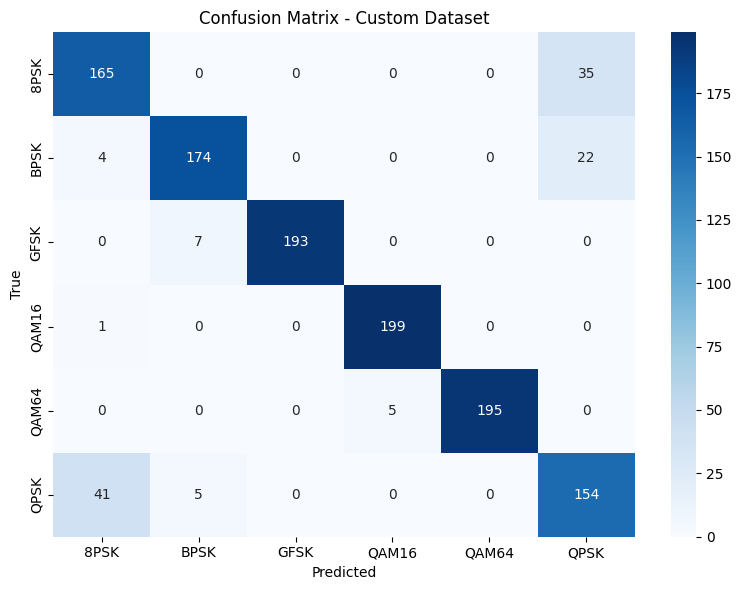

In [15]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------
# Load Signals and Labels
# -------------------------------
signals = np.load("dataset_M0/signals.npy")
labels = np.load("dataset_M0/labels.npy")

# -------------------------------
# Load Saved Model and Pipeline
# -------------------------------
svm_model = joblib.load("models/custom_linear_svm_model.pkl")
scaler = joblib.load("models/custom_scaler.pkl")
pca = joblib.load("models/custom_pca.pkl")
poly = joblib.load("models/custom_poly.pkl")
label_encoder = joblib.load("models/custom_label_encoder.pkl")

# -------------------------------
# Feature Extraction (Same as Training)
# -------------------------------
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.nan_to_num(np.abs(signal))
        signal_skew = skew(signal)
        signal_kurtosis = kurtosis(signal)
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
        mad = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        activity = np.var(signal)
        mobility = np.sqrt(np.var(np.diff(signal)) / activity) if activity != 0 else 0
        complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / mobility) if mobility != 0 else 0
        fft_signal = np.abs(fft(signal))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid)**2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2 + 1e-10)
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal, 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conj(signal))
        M22 = np.mean(np.conj(signal)**2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conj(signal))
        M42 = np.mean(signal**2 * np.conj(signal)**2)
        M43 = np.mean(signal * np.conj(signal)**3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21)**2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * M20**2 - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([
            signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
            mad, shannon_entropy, activity, mobility, complexity,
            fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
            fft_low, fft_mid, fft_high,
            wavelet_energy, wavelet_entropy, wavelet_detail_energy,
            M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120,
            C20, C40, C41, C42, C60, C80, C100,
            r1, r2, r16, r17, r18, r19, r20, papr, crest_factor
        ])
    return np.array(features)

# -------------------------------
# Feature Extraction & Prediction
# -------------------------------
X = extract_features(signals)
X_scaled = scaler.transform(X)
X_pca = pca.transform(X_scaled)
X_poly = poly.transform(X_pca)

y_true = label_encoder.transform(labels)
y_pred = svm_model.predict(X_poly)

# -------------------------------
# Evaluation
# -------------------------------
#print("\nClassification Report:")
#print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Custom Dataset")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))




In [27]:
import numpy as np
import joblib
import os
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# -------------------------------
# Load the Training Dataset
# -------------------------------
dataset_path = "dataset_200"
train_signals = np.load(os.path.join(dataset_path, "200_train_signals.npy"))
train_labels = np.load(os.path.join(dataset_path, "200_train_labels.npy"))

# Encode Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_labels)

# -------------------------------
# Feature Extraction Function
# -------------------------------
def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.abs(signal)
        
        # Statistical Features
        signal_skew = skew(signal)
        signal_kurtosis = kurtosis(signal)
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
        mad = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        activity = np.var(signal)
        mobility = np.sqrt(np.var(np.diff(signal)) / activity) if activity != 0 else 0
        complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / mobility) if mobility != 0 else 0

        # FFT-Based Features
        fft_signal = np.abs(fft(signal))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid)**2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2 + 1e-10)
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])

        # Wavelet Features
        coeffs = pywt.wavedec(signal, 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))

        # Higher-Order Cumulants (HOC)
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conj(signal))
        M22 = np.mean(np.conj(signal)**2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conj(signal))
        M42 = np.mean(signal**2 * np.conj(signal)**2)
        M43 = np.mean(signal * np.conj(signal)**3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)

        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21)**2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * M20**2 - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20

        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0

        # Additional Features
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([
            signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
            mad, shannon_entropy, activity, mobility, complexity,
            fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
            fft_low, fft_mid, fft_high,
            wavelet_energy, wavelet_entropy, wavelet_detail_energy,
            M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120,
            C20, C40, C41, C42, C60, C80, C100,
            r1, r2, r16, r17, r18, r19, r20, papr, crest_factor
        ])
    return np.array(features)

# -------------------------------
# Feature Extraction
# -------------------------------
X = extract_features(train_signals)

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

# Polynomial Expansion
poly = PolynomialFeatures(degree=2, interaction_only=True)
X_poly = poly.fit_transform(X_pca)

# -------------------------------
# Train Linear SVM with Grid Search
# -------------------------------
param_grid = {"C": [0.01, 0.1, 1, 10]}
svm_grid = GridSearchCV(SVC(kernel="linear", class_weight="balanced"), param_grid, cv=4, n_jobs=-1, verbose=1)
svm_grid.fit(X_poly, y_encoded)

# -------------------------------
# Save Trained Model & Pipeline
# -------------------------------
best_svm = svm_grid.best_estimator_
os.makedirs("models", exist_ok=True)
joblib.dump(best_svm, "models/200_custom_linear_svm_model.pkl")
joblib.dump(scaler, "models/200_custom_scaler.pkl")
joblib.dump(pca, "models/200_custom_pca.pkl")
joblib.dump(poly, "models/200_custom_poly.pkl")
joblib.dump(label_encoder, "models/200_custom_label_encoder.pkl")

print("✅ Model and preprocessing pipeline saved to 'models/' folder.")


Fitting 4 folds for each of 4 candidates, totalling 16 fits
✅ Model and preprocessing pipeline saved to 'models/' folder.


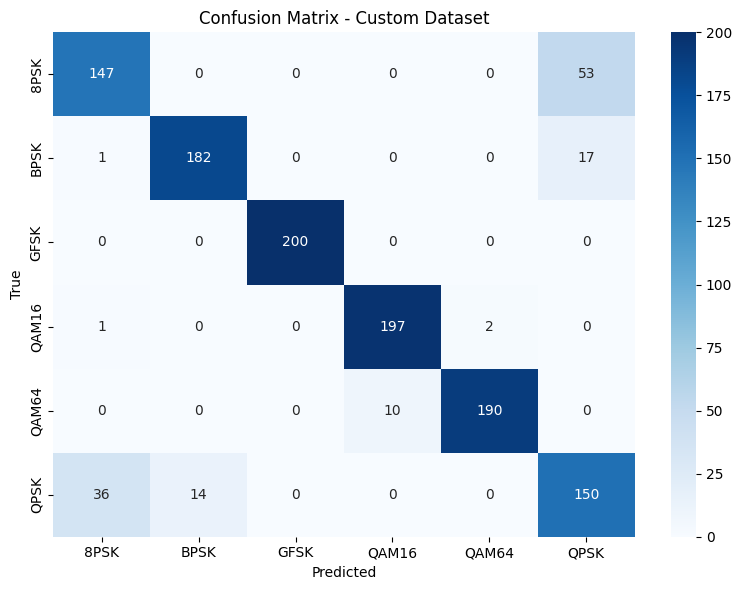


Classification Report:
              precision    recall  f1-score   support

        8PSK       0.79      0.73      0.76       200
        BPSK       0.93      0.91      0.92       200
        GFSK       1.00      1.00      1.00       200
       QAM16       0.95      0.98      0.97       200
       QAM64       0.99      0.95      0.97       200
        QPSK       0.68      0.75      0.71       200

    accuracy                           0.89      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.89      0.89      0.89      1200



In [3]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------
# Load Signals and Labels
# -------------------------------
signals = np.load("dataset_200/200_test_signals_snr8.npy")
labels = np.load("dataset_200/200_test_labels_snr8.npy")

# -------------------------------
# Load Saved Model and Pipeline
# -------------------------------
svm_model = joblib.load("models/200_custom_linear_svm_model.pkl")
scaler = joblib.load("models/200_custom_scaler.pkl")
pca = joblib.load("models/200_custom_pca.pkl")
poly = joblib.load("models/200_custom_poly.pkl")
label_encoder = joblib.load("models/200_custom_label_encoder.pkl")

# -------------------------------
# Feature Extraction (Same as Training)
# -------------------------------
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.nan_to_num(np.abs(signal))
        signal_skew = skew(signal)
        signal_kurtosis = kurtosis(signal)
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal)) != 0) / len(signal)
        mad = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        activity = np.var(signal)
        mobility = np.sqrt(np.var(np.diff(signal)) / activity) if activity != 0 else 0
        complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / mobility) if mobility != 0 else 0
        fft_signal = np.abs(fft(signal))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid)**2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2 + 1e-10)
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal, 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conj(signal))
        M22 = np.mean(np.conj(signal)**2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conj(signal))
        M42 = np.mean(signal**2 * np.conj(signal)**2)
        M43 = np.mean(signal * np.conj(signal)**3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21)**2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * M20**2 - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([
            signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
            mad, shannon_entropy, activity, mobility, complexity,
            fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
            fft_low, fft_mid, fft_high,
            wavelet_energy, wavelet_entropy, wavelet_detail_energy,
            M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120,
            C20, C40, C41, C42, C60, C80, C100,
            r1, r2, r16, r17, r18, r19, r20, papr, crest_factor
        ])
    return np.array(features)

# -------------------------------
# Feature Extraction & Prediction
# -------------------------------
X = extract_features(signals)
X_scaled = scaler.transform(X)
X_pca = pca.transform(X_scaled)
X_poly = poly.transform(X_pca)

y_true = label_encoder.transform(labels)
y_pred = svm_model.predict(X_poly)

# -------------------------------
# Evaluation
# -------------------------------
#print("\nClassification Report:")
#print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Custom Dataset")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


